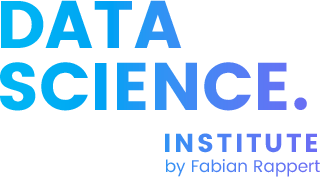

# Funktionen höherer Ordnung

In Python sind Funktionen nicht nur Codeblöcke, die bestimmte Aufgaben ausführen, sondern sie werden auch als Objekte behandelt. Das bedeutet, dass wir Funktionen genauso wie andere Datenwerte verwenden können - wir können sie beispielsweise als Argumente an andere Funktionen übergeben. 

Funktionen, die andere Funktionen als Argumente entgegennehmen oder als Ergebnis zurückliefern, werden **Funktionen höherer Ordnung** genannt. 


## Funktionen als Argumente übergeben

### Beispiel 1: Flexibles Bearbeiten von Listen

Angenommen, wir arbeiten mit einer Liste von Zahlen und möchten diese nach verschiedenen Kriterien bearbeiten. Statt für jede Bearbeitungsart eine separate Funktion zu schreiben, können wir eine universelle Funktion `edit_list` erstellen. Diese Funktion ermöglicht es uns, die Art der Bearbeitung dynamisch zu bestimmen, indem wir eine andere Funktion als Argument übergeben. Diese übergebene Funktion definiert, wie jedes Element der Liste verändert wird. 

Dieser Ansatz macht unseren Code flexibler und wiederverwendbarer, da `edit_list` mit verschiedenen Funktionen als Argumente für unterschiedliche Bearbeitungsoperationen genutzt werden kann.


In [ ]:
def edit_list(func, my_list):
    
    for element in my_list:
        print(func(element))


Die Funktion `edit_list` akzeptiert zwei Argumente:

- `func`: Eine Funktion, die als Argument eine Zahl entgegennimmt, eine Operation darauf ausführt und als Ergebnis eine Zahl zurückliefert.
- `my_list`: Eine Liste von Zahlen, die modifiziert werden sollen.

Innerhalb von `edit_list` wird das übergebene Argument `func` sequenziell auf jedes Element in `my_list` angewandt, und das resultierende Ergebnis wird für jedes Element ausgegeben.

Um die Anwendbarkeit und Flexibilität von `edit_list` zu veranschaulichen, testen wir sie mit einer spezifischen Funktion, die jede Zahl verdoppelt. Dies demonstriert, wie `edit_list` es ermöglicht, unterschiedliche Bearbeitungsfunktionen auf die Elemente einer Liste anzuwenden.


In [ ]:
def double_number(x):    
    return 2 * x


In [ ]:
numbers = [1, 2, 3]
edit_list(double_number, numbers)


Wir können jedoch auch eine andere Funktion übergeben, die z.B. jede Zahl quadriert:

In [ ]:
def square_number(x):
    return x * x


In [ ]:
edit_list(square_number, numbers)


Oder eine Funktion, die von jeder Zahl $y$ den Kehrwert berechnet:

In [ ]:
def reciprocal_number(y):
    return 1 / y


In [ ]:
edit_list(reciprocal_number, numbers)


> <span style="color:gray"> **HINWEIS:** </span> Bei der Funktion `reciprocal` kann es eventuell Probleme geben. Siehst du welche? Mache dir Gedanken über eine Lösung.

## Eine Funktion, die eine Funktion zurückgibt

Wie bereits diskutiert, können die Rückgabewerte einer Funktion vielfältig sein; sie sind nicht auf primitive Datentypen wie Zahlen oder Zeichenketten beschränkt. Eine besondere und mächtige Eigenschaft von Funktionen in Python ist, dass sie auch andere Funktionen als Rückgabewerte liefern können. 

Im nächsten Beispiel betrachten wir, wie eine solche Struktur in der Praxis aussieht und welche Potenziale sie birgt.


In [ ]:
def get_hello_function():
    
    def say_hello():
        print("Hello")
    
    return say_hello

hello_function = get_hello_function()
hello_function()


Wir starten mit einer Funktion `get_hello_function`, die eine innere Funktion `say_hello` definiert, welche "Hello" ausgibt. `get_hello_function` gibt diese innere Funktion zurück. Nach dem Aufrufen von `get_hello_function` erhalten wir also eine Funktion, die wir mit `hello_function()` ausführen können.

Obwohl dieses Beispiel die Fähigkeit von Funktionen demonstriert, andere Funktionen zurückzugeben, ist es in seiner Anwendung noch recht einfach gehalten. 
<br>Ein praktischeres Beispiel betrachten wir mit der Funktion `create_adder`, die eine Zahl `x` als Argument nimmt. 

`create_adder` gibt eine neue Funktion zurück, die zu ihrem Argument den Wert `x` addiert, was die Vielseitigkeit und den Nutzen von Funktionen als Rückgabewerte verdeutlicht.


In [ ]:
def create_adder(x):
    def adder(y):
        return x + y
    return adder


Wir können nun zwei neue Funktionen erhalten:

In [ ]:
add_with_10 = create_adder(10)
add_with_20 = create_adder(20)


- Die erste Funktion, `add_with_10` addiert auf ihr Argument immer die Zahl 10.
- Die zweite Funktion, `add_with_20` addiert auf ihr Argument immer die Zahl 20.

In [ ]:
x = add_with_10(10)
y = add_with_20(10)
print(f"10 nach Anwendung von add_with_10: {x}")
print(f"10 nach Anwendung von add_with_20: {y}")



# Mathematischer Einschub

## Beispiel 2 - Funktionen verknüpfen

Gegeben sind die Funktionen $f(x)=x^2$ und $g(x)=x+5$.

Wie können wir nun die zwei neuen Funktionen $h(x) = f(g(x))$ und $k(x) = g(f(x))$ in Python erhalten?

Mit **Funktionen höherer Ordnung** können wir diese mathematischen Funktionen in Python verknüpfen.

Wir beginnen mit den Grundfunktionen `f` und `g`. Dann zeigen wir, wie wir mit einer höheren Funktion `combine_functions` zwei Funktionen miteinander verknüpfen können. 

In [ ]:
def f(x):
    return x ** 2

def g(x):
    return x + 5


`combine_functions` nimmt zwei Funktionen, `func1` und `func2`, als Argumente und gibt eine neue Funktion zurück, die `func1` und `func2` in der angegebenen Reihenfolge kombiniert.

In [ ]:
def combine_functions(func1, func2):
    def combined_function(x):
        return func2(func1(x))
    return combined_function


Nun können wir die Funktion $h(x) = f(g(x))$ ganz einfach erzeugen:

In [ ]:
h = combine_functions(g, f) # Die Reihenfolge ist wichtig, da g(f(x))


Als Test können wir uns den Wert $h(3)$ ausrechnen und mit unserer Python-Funktion $h$ vergleichen:


\begin{align}
h(3) &=f(g(3)) \\
&= f(3+5) \\
&= f(8) \\
&= 8^2 \\
&= 64 \\
\end{align}

In [ ]:
print(f"Wir übergeben 3 als Argument an h und erhalten: {h(3)}")
